# Stroj - Primeiro Challenge - Dataset

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import re

## Pré processamento dos datasets

### Dataset 1 - Fake.br Corpus

https://github.com/jpchav98/FakeTrue.Br

Corpus Fake News em Português
Corpus para detecção automática de fake news em português, organizado em três versões:
- full_texts → textos completos + metadados de notícias fake e true.
- size_normalized_texts → pares fake/true com textos equalizados em número de palavras, reduzindo viés nos experimentos de ML.
- preprocessed → CSV com textos pré-processados (stopwords, acentos/diacríticos removidos).

Os pares fake/true são identificados pelo mesmo número/nome.
Metadados: autoria, categoria, data, tamanho textual, verbos, substantivos, adjetivos, pronomes, emotividade, diversidade etc.

Referências principais: Monteiro et al. (2018) — PROPOR; Silva et al. (2020) — Expert Systems with Applications.

In [61]:
df1 = pd.read_csv("input_datasets/size_normalized.csv")
df1['label'] = df1['label'].map({'fake':0,'true':1})
df1 = df1.drop_duplicates()
df1

,text,label
0,Kátia Abreu diz que vai colocar sua expulsão e...,0
1,"Dr. Ray peita Bolsonaro, chama-o de “conservad...",0
2,Reinaldo Azevedo desmascarado pela Polícia Fed...,0
3,Relatório assustador do BNDES mostra dinheiro ...,0
4,"Radialista americano fala sobre o PT: ""Eles ve...",0
...,...,...
7195,"Para jornal britânico, ação contra Lula na Lav...",1
7196,Temer diz que acionou PF e Cade para investiga...,1
7197,Os obstáculos políticos de Temer em 2017. Espe...,1
7198,"Sexta-feira, 15 de setembro de 2017. Boa noite...",1


### Dataset 2 - FakeTrue.Br



https://github.com/jpchav98/FakeTrue.Br

FakeTrueBr is a corpus that contains a collection of fake and true news, carefully aligned with each other. Each fake news article in the corpus has its corresponding true news article that is thematically related. In total, this corpus includes 3582 news articles.

The fake news articles were collected from the verification agency Boatos.org using a crawler, allowing us to gather a diverse sample of fake news. Additionally, we developed a methodology and a custom crawler to extract news articles that were topically related to the previously collected fake news. These true news articles were collected from trustworthy journalistic sources such as G1 Globo and Folha de S.Paulo.

If you're interested in learning more details about the creation of this corpus or the classification results we obtained, we invite you to consult our publication presented at the XVIII Escola Regional de Banco de Dados. You can access the full article here.

In [62]:
df2 = pd.read_csv("input_datasets/FakeTrueBr_corpus.csv")
df2 = df2.drop(columns=['title_fake', 'link_f', 'link_t'])
df2 = pd.concat([
    df2[["fake"]].rename(columns={"fake": "text"}).assign(label=0),
    df2[["true"]].rename(columns={"true": "text"}).assign(label=1)
], ignore_index=True)
df2 = df2.drop_duplicates()
df2

,text,label
0,carnaval em olinda. arrastão monstro. fazuele ...,0
1,carro alegórico da escola de samba grande rio...,0
2,cantor léo apoiando atos antidemocráticos. alg...,0
3,versão 1 ore muito pela cantora anitta! ela es...,0
4,morre erasmo carlos aos 81 anos cantor conside...,0
...,...,...
3577,O preço médio da gasolina nos postos do Brasi...,1
3578,Não há nenhuma comprovação que vacinas contra...,1
3579,A seringa que foi usada por uma técnica de en...,1
3580,A SESAI (Secretaria Especial de Saúde Indígen...,1


### Dataset 3 - Fake news in Portuguese

https://www.kaggle.com/datasets/fabioselau/fakes-news-portuguese?select=fakes.csv

Dataset containing 20k news records categorized as fake news and 2k news classified as true.

It was separated into two spreadsheets, one containing only fake news (label = 1) and the other containing only true news (label = 0).

In [63]:
df3_fake = pd.read_csv("input_datasets/fakes.csv")
df3_true = pd.read_csv("input_datasets/true.csv")
df3_fake["label"] = 0
df3_true["label"] = 1
df3 = pd.concat([df3_fake, df3_true], ignore_index=True)
df3 = df3.drop(columns=['title', 'origin', 'url', 'publisher_name', 'publisher_site', 'date'])
df3 = df3.drop_duplicates()
df3

,text,label
0,“Nando Reis se F… Se F…. no Rock in Rio”,0
1,"“Não foi dinheiro vivo. Moeda corrente, quer d...",0
2,"“Em seus últimos momentos de vida, rainha Eliz...",0
3,“TSE MARCOU PARA PRÓXIMA SEMANA JULGAMENTO OND...,0
4,"De repente, a Ivermectina aparece no site do N...",0
...,...,...
23193,Teste em cão dá positivo para o novo coronavírus,1
23194,Está com suspeita de coronavírus leva o kit pr...,1
23195,Bolsonaro afirmou em 2018 que o indulto de Nat...,1
23196,Jair Bolsonaro declarou que a chegada de Hugo ...,1


### Dataset 4 - Notícias publicadas no Brasil

https://www.kaggle.com/datasets/diogocaliman/notcias-publicadas-no-brasil

Este dataset contém uma compilação de matérias extraídas dos sites do grupo globo.
São mais de 10 mil matérias, publicadas entre 2014 e 2020.

In [64]:
df4 = pd.read_csv("input_datasets/Historico_de_materias.csv")
df4 = df4.drop(columns=['data', 'url_noticia', 'url_noticia_curto', 'titulo', 'assunto'])
df4 = df4.rename(columns={"conteudo_noticia": "text"})
df4['label'] = 1
df4 = df4.drop_duplicates()
df4 = df4[df4['text'].str.split().str.len() > 6]
df4

,text,label
0,"\n\tA alta de 15% no dólar em 2013, a maior do...",1
1,\n\tA presidente Dilma Rousseff afirmou nesta ...,1
2,"\n\tO presidente do Banco Central, Alexandre T...",1
3,\n\tO governo argentino anunciou nesta sexta-f...,1
4,\n\tA Petrobras afirmou que propôs à Agência N...,1
...,...,...
10104,"Em apenas 1 ano, o número de internautas no B...",1
10105,A Coreia do Norte costuma ostentar seu aparat...,1
10106,As vendas de computadores no Brasil desaceler...,1
10107,O Instagram liberou na tarde desta quinta-fei...,1


## Junção dos datasets

In [65]:
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
df['text'] = df['text'].str.replace(r'[\r\n\t]', '', regex=True)
df = df.drop_duplicates()

#### Informações sobre o dataset

In [66]:
print(f"Quantidade de notícias: {df.shape[0]} (fake: {df['label'].value_counts()[0]}, true: {df['label'].value_counts()[1]})")
print(f"Quantidade de dados duplicados: {df["text"].duplicated().sum()}")
print(f"Quantidade de dados vazios: {df.isnull().sum().sum()}")
print(f"Menor tamanho: {df["text"].str.split().str.len().min()}")

Quantidade de notícias: 43577 (fake: 25782, true: 17795)
Quantidade de dados duplicados: 0
Quantidade de dados vazios: 0
Menor tamanho: 1


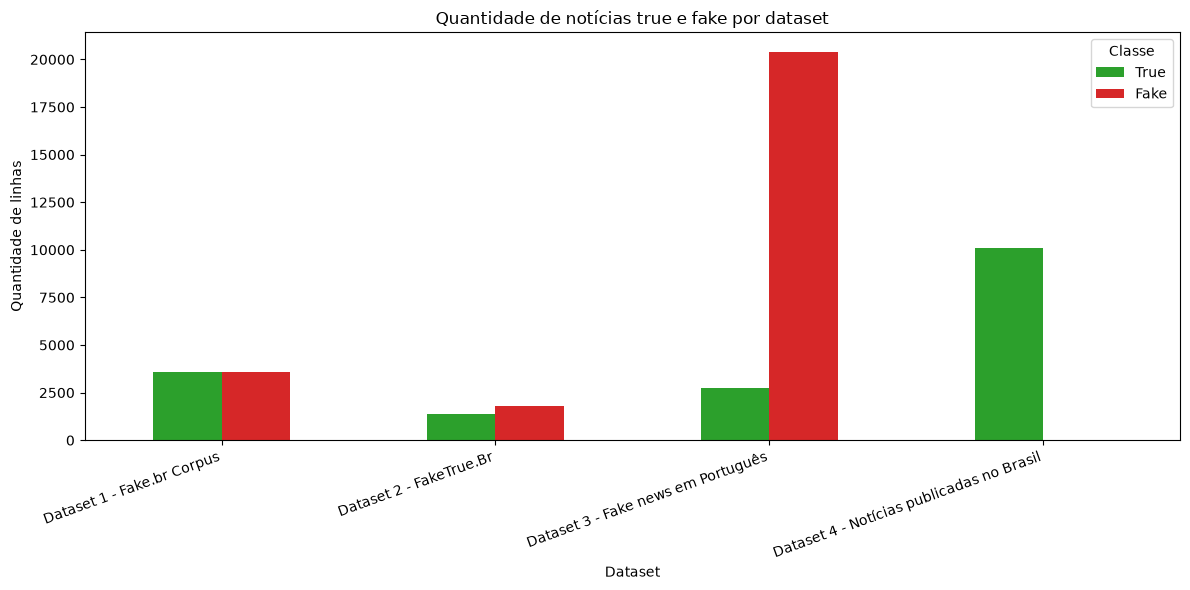

,Dataset 1 - Fake.br Corpus,Dataset 2 - FakeTrue.Br,Dataset 3 - Fake news em Português,Dataset 4 - Notícias publicadas no Brasil
True,3599,1403,2717,10076.0
Fake,3600,1780,20402,NaN


In [67]:
# Quantidade de notícias true e fake por dataset
contagens = pd.DataFrame({
    "Dataset 1 - Fake.br Corpus": df1["label"].value_counts(),
    "Dataset 2 - FakeTrue.Br": df2["label"].value_counts(),
    "Dataset 3 - Fake news em Português": df3["label"].value_counts(),
    "Dataset 4 - Notícias publicadas no Brasil": df4["label"].value_counts(),
}).reindex([1, 0], fill_value=0)

contagens.index = ["True", "Fake"]

ax = contagens.T.plot(kind="bar", figsize=(12, 6), color=["#2ca02c", "#d62728"])
ax.set_title("Quantidade de notícias true e fake por dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Quantidade de linhas")
ax.legend(title="Classe")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

contagens

## Pós processamento dos datasets

In [68]:
textos = df["text"]

# 1. Caixa alta é predominante
# Considera apenas letras e verifica se mais de 50% estão em maiúsculas
def caixa_alta_predominante(text):
    letras = [c for c in text if c.isalpha()]
    
    if not letras:
        return False
    
    maiusculas = sum(c.isupper() for c in letras)
    return maiusculas / len(letras) > 0.5


# 2. Mais de um ponto de exclamação seguido
def multiplas_exclamacoes(text):
    return bool(re.search(r"!{2,}", text))


# 3. Mais de um ponto de interrogação seguido
def multiplas_interrogacoes(text):
    return bool(re.search(r"\?{2,}", text))


# 4. Caracteres especiais
def possui_caracteres_especiais(text):
    return bool(re.search(r"[#@$%*_+=<>|~^]", text))

# 5. Espaçamentos em excesso
#def possui_espacamentos_excessivos(text):
#    return bool(re.search(r"\s{2,}", text))

# Criar características
df_analise = pd.DataFrame({
    "label": df["label"],
    "caixa_alta": textos.apply(caixa_alta_predominante),
    "multiplas_exclamacoes": textos.apply(multiplas_exclamacoes),
    "multiplas_interrogacoes": textos.apply(multiplas_interrogacoes),
    "caracteres_especiais": textos.apply(possui_caracteres_especiais),
    #"espacamentos_excessivos": textos.apply(possui_espacamentos_excessivos)
})

# Quantidade por label
print("QUANTIDADE DE TEXTOS COM CADA CARACTERÍSTICA")
print("=" * 60)

print(
    df_analise
    .groupby("label")
    .sum(numeric_only=True)
)


# Porcentagem por label
print("\n\nPORCENTAGEM DE TEXTOS COM CADA CARACTERÍSTICA")
print("=" * 60)

print(
    df_analise
    .groupby("label")
    .mean(numeric_only=True)
    .mul(100)
    .round(2)
)

QUANTIDADE DE TEXTOS COM CADA CARACTERÍSTICA
       caixa_alta  multiplas_exclamacoes  multiplas_interrogacoes  \
label                                                               
0             442                    708                      201   
1               9                    121                       24   

       caracteres_especiais  
label                        
0                      3281  
1                      6962  


PORCENTAGEM DE TEXTOS COM CADA CARACTERÍSTICA
       caixa_alta  multiplas_exclamacoes  multiplas_interrogacoes  \
label                                                               
0            1.71                   2.75                     0.78   
1            0.05                   0.68                     0.13   

       caracteres_especiais  
label                        
0                     12.73  
1                     39.12  


In [69]:
# Adicionar as colunas ao DataFrame original
df["caixa_alta"] = textos.apply(caixa_alta_predominante).map({False:0,True:1})
df["multiplas_exclamacoes"] = textos.apply(multiplas_exclamacoes).map({False:0,True:1})
df["multiplas_interrogacoes"] = textos.apply(multiplas_interrogacoes).map({False:0,True:1})
df["caracteres_especiais"] = textos.apply(possui_caracteres_especiais).map({False:0,True:1})
df

,text,label,caixa_alta,multiplas_exclamacoes,multiplas_interrogacoes,caracteres_especiais
0,Kátia Abreu diz que vai colocar sua expulsão e...,0,0,0,0,0
1,"Dr. Ray peita Bolsonaro, chama-o de “conservad...",0,0,0,0,1
2,Reinaldo Azevedo desmascarado pela Polícia Fed...,0,0,0,0,0
3,Relatório assustador do BNDES mostra dinheiro ...,0,0,0,0,1
4,"Radialista americano fala sobre o PT: ""Eles ve...",0,0,0,0,0
...,...,...,...,...,...,...
43572,"Em apenas 1 ano, o número de internautas no B...",1,0,0,0,1
43573,A Coreia do Norte costuma ostentar seu aparat...,1,0,0,0,0
43574,As vendas de computadores no Brasil desaceler...,1,0,0,0,1
43575,O Instagram liberou na tarde desta quinta-fei...,1,0,0,0,0


## Exportação do dataset

In [70]:
df.to_csv('dataset.csv', index_label="id")